# Module 4 — In-Depth Analysis & Final Validation
## Ohio Dental Clinic — Site Selection Analysis

**Purpose:** In-depth competitive analysis and final validation. Cross-validates DSO counts using brand-name verification against 5 major Ohio chains (Aspen Dental, Heartland Dental, Great Expressions, Dental Care Alliance, Bright Now / Smile Brands). Builds pairwise head-to-head comparison matrix for all Columbus locations. Conducts Ontario standalone revenue analysis. Confirms final location rankings.

| | |
|---|---|
| **Input** | `master_dataset.csv`, `module2_scores.csv` |
| **Output** | `module4_final_scores.csv`, `module4_tradeoff.csv`, 6 chart PNGs |
| **Key finding** | Lewis Center wins all 4 Columbus head-to-head comparisons — DSO penetration confirmed at 4.1%, below Columbus average |

In [2]:
# LIBRARIES 
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# PATHS 
DATA_PATH    = r"../outputs"
CLEANED_PATH = r"../data/cleaned"
OUTPUT_PATH  = r"../outputs"
CHARTS_PATH  = r"../charts/charts_m4"

os.makedirs(CHARTS_PATH, exist_ok=True)

# CHART STYLE 
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "figure.dpi":        150,
})

# CONSTANTS 
COLOR_MAP = {
    "Ontario":       "#0F2240",
    "Westerville":   "#0D8C7A",
    "Sawmill Rd":    "#E8A730",
    "Lewis Center":  "#C0392B",
    "Indianola Ave": "#5B5EA6",
    "Hamilton Rd":   "#2E86AB",
}

NAME_MAP = {
    1: "Ontario",
    2: "Westerville",
    3: "Sawmill Rd",
    4: "Lewis Center",
    5: "Indianola Ave",
    6: "Hamilton Rd",
}

ZIP_COL   = "Provider Business Practice Location Address Postal Code"
STATE_COL = "Provider Business Practice Location Address State Name"
ORG_COL   = "Provider Organization Name (Legal Business Name)"

print("Setup complete.")

Setup complete.


In [3]:
# NORMALIZATION
def normalize(series, invert=False):
    """Min-max normalize a series to 0-100. Invert = lower raw = higher score."""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([50.0] * len(series), index=series.index)
    norm = (series - mn) / (mx - mn) * 100
    return 100 - norm if invert else norm

# HAVERSINE
def haversine(lat1, lon1, lat2, lon2):
    """Calculate straight-line distance in miles between two lat/lon points."""
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

print("Helper functions defined.")

Helper functions defined.


In [4]:
# LOAD ALL PRIOR OUTPUTS 
master = pd.read_csv(os.path.join(DATA_PATH, "master_dataset.csv"))
scores = pd.read_csv(os.path.join(DATA_PATH, "module2_scores.csv"))

# Clean up _x/_y suffixes from Module 1 internal merge
rename_map = {c: c.replace("_x", "") for c in master.columns if c.endswith("_x")}
master = master.rename(columns=rename_map)
master = master[[c for c in master.columns if not c.endswith("_y")]]

df = master.merge(scores, on=["location_id", "location_name"], how="left")

print(f"Working table: {len(df)} rows x {len(df.columns)} columns")
print(f"Locations: {df['location_name'].tolist()}")

Working table: 6 rows x 43 columns
Locations: ['Ontario', 'Westerville', 'Sawmill Rd', 'Lewis Center', 'Indianola Ave', 'Hamilton Rd']


In [5]:
# FINAL SCORING
# Weights held constant from Module 2 — sensitivity analysis confirmed robustness.
# Population 30% | Income 30% | Competition 25% | Medicaid 15%

W = {"pop": 0.30, "inc": 0.30, "comp": 0.25, "med": 0.15}

df["n_pop"]  = normalize(df["total_population"])
df["n_inc"]  = normalize(df["median_income"])
df["n_comp"] = normalize(df["total_15min"], invert=True)
df["n_med"]  = normalize(df["medicaid_pct"], invert=True)

df["final_score"] = (
    df["n_pop"]  * W["pop"] +
    df["n_inc"]  * W["inc"] +
    df["n_comp"] * W["comp"] +
    df["n_med"]  * W["med"]
).round(1)

df["final_rank"] = df["final_score"].rank(ascending=False).astype(int)
df["market_gap"] = normalize(
    df["total_population"] * (df["median_income"] / df["median_income"].mean()) / df["total_15min"]
)
df["residents_per_dentist"] = (df["total_population"] / df["total_15min"]).round(0)
df_ranked = df.sort_values("final_score", ascending=False)

print("FINAL SCORES")
print("=" * 65)
for _, row in df_ranked.iterrows():
    print(f"  #{int(row['final_rank'])}  {row['location_name']:<16}  "
          f"Score={row['final_score']:.1f}  "
          f"Pop={row['n_pop']:.1f}  "
          f"Inc={row['n_inc']:.1f}  "
          f"Comp={row['n_comp']:.1f}  "
          f"Med={row['n_med']:.1f}  "
          f"GapIdx={row['market_gap']:.1f}  "
          f"Res/Dentist={row['residents_per_dentist']:,.0f}")

df_ranked.to_csv(os.path.join(OUTPUT_PATH, "module4_final_scores.csv"), index=False)
print("\nSaved: module4_final_scores.csv")

FINAL SCORES
  #1  Lewis Center      Score=81.0  Pop=89.5  Inc=100.0  Comp=48.1  Med=80.8  GapIdx=100.0  Res/Dentist=2,029
  #2  Sawmill Rd        Score=79.4  Pop=92.1  Inc=100.0  Comp=27.1  Med=100.0  GapIdx=47.4  Res/Dentist=1,548
  #3  Westerville       Score=74.2  Pop=91.5  Inc=90.8  Comp=27.3  Med=84.6  GapIdx=43.3  Res/Dentist=1,544
  #4  Hamilton Rd       Score=69.8  Pop=92.5  Inc=68.2  Comp=42.4  Med=73.1  GapIdx=71.6  Res/Dentist=1,913
  #5  Indianola Ave     Score=60.0  Pop=100.0  Inc=53.9  Comp=0.0  Med=92.3  GapIdx=0.0  Res/Dentist=1,250
  #6  Ontario           Score=25.0  Pop=0.0  Inc=0.0  Comp=100.0  Med=0.0  GapIdx=32.1  Res/Dentist=1,843

Saved: module4_final_scores.csv


In [8]:
# DSO CROSS-VALIDATION
# Validates keyword-based DSO classification from Module 1 against known
# Ohio DSO brand names. If brand counts are lower than keyword counts,
# the keyword method is conservative — not inflated.

DSO_BRANDS = {
    "Aspen Dental":        ["ASPEN DENTAL"],
    "Heartland Dental":    ["HEARTLAND DENTAL"],
    "Great Expressions":   ["GREAT EXPRESSIONS"],
    "DCA / Dental Care":   ["DENTAL CARE ALLIANCE", "DCA DENTAL"],
    "Bright Now / Smile":  ["BRIGHT NOW", "SMILE BRANDS", "CASTLE DENTAL"],
    "Other DSO (keyword)": ["DENTAL GROUP", "DENTAL ASSOCIATES", "DENTAL PARTNERS",
                            "FAMILY DENTAL", "DENTISTRY LLC", "DENTAL CENTER",
                            "DENTAL CARE", "DENTAL SERVICES", "DENTAL MGMT",
                            "SMILE DENTAL", "PERFECT SMILE", "COMFORT DENTAL"],
}

def flag_dso_brand(org_name):
    for brand, keywords in DSO_BRANDS.items():
        for kw in keywords:
            if kw in org_name:
                return brand
    return None

print("Loading NPI data for DSO cross-validation...")

npi = pd.read_csv(os.path.join(CLEANED_PATH, "NPI_Dentists.csv"), dtype=str, low_memory=False)
npi[ZIP_COL] = npi[ZIP_COL].str[:5].str.strip()
npi_oh = npi[npi[STATE_COL].str.strip().str.upper() == "OH"].copy()
npi_oh["org_upper"] = npi_oh[ORG_COL].fillna("").str.upper()
npi_oh["dso_brand"] = npi_oh["org_upper"].apply(flag_dso_brand)
npi_dso = npi_oh[npi_oh["dso_brand"].notna()].copy()

print(f"DSO brand matches in Ohio NPI: {len(npi_dso)}")
print("\nBy brand:")
print(npi_dso["dso_brand"].value_counts().to_string())

# Join DSO providers to ZIP centroids
zip_cents = pd.read_csv(os.path.join(CLEANED_PATH, "ohio_zip_centroids_cleaned.csv"), dtype={"zip": str})
zip_cents["zip"] = zip_cents["zip"].str[:5].str.strip()

npi_dso_geo = npi_dso.merge(
    zip_cents[["zip", "latitude", "longitude"]],
    left_on=ZIP_COL, right_on="zip", how="inner"
)

# Load locations
locs_master = pd.read_csv(os.path.join(CLEANED_PATH, "locations_master_cleaned.csv"))
locs_master.columns = locs_master.columns.str.strip().str.lower().str.replace(" ", "_")
locs_master["location_name"] = locs_master["location_id"].map(NAME_MAP)

# Count DSO brands within 15 miles of each location
dso_results = []
for _, loc in locs_master.iterrows():
    dists = haversine(loc["latitude"], loc["longitude"],
                      npi_dso_geo["latitude"].values, npi_dso_geo["longitude"].values)
    within_15    = npi_dso_geo[dists <= 9].copy()
    brand_counts = within_15["dso_brand"].value_counts().to_dict()
    total_brand  = len(within_15)
    dso_results.append({
        "location_name":         loc["location_name"],
        "dso_brand_total_15min": total_brand,
        **{f"brand_{k.split('/')[0].strip().lower().replace(' ','_')}": v
           for k, v in brand_counts.items()}
    })

dso_df = pd.DataFrame(dso_results)

# Compare with original keyword DSO counts
dso_compare = df[["location_name", "dso_15min", "total_15min"]].merge(
    dso_df[["location_name", "dso_brand_total_15min"]], on="location_name", how="left"
)
dso_compare["keyword_dso_pct"] = (dso_compare["dso_15min"] / dso_compare["total_15min"] * 100).round(1)
dso_compare["brand_dso_pct"]   = (dso_compare["dso_brand_total_15min"] / dso_compare["total_15min"] * 100).round(1)
dso_compare["gap"]             = (dso_compare["dso_brand_total_15min"] - dso_compare["dso_15min"])

print("\nDSO CROSS-VALIDATION RESULTS (15-min radius)")
print("=" * 70)
print(f"{'Location':<16} {'Keyword DSO':>12} {'Brand DSO':>10} {'Kw%':>6} {'Brand%':>8} {'Gap':>6}")
print("-" * 70)
for _, row in dso_compare.iterrows():
    print(f"  {row['location_name']:<14} {int(row['dso_15min']):>12} "
          f"{int(row['dso_brand_total_15min']):>10} "
          f"{row['keyword_dso_pct']:>6.1f}% "
          f"{row['brand_dso_pct']:>7.1f}% "
          f"{int(row['gap']):>6}")

Loading NPI data for DSO cross-validation...
DSO brand matches in Ohio NPI: 442

By brand:
dso_brand
Other DSO (keyword)    437
Heartland Dental         4
Aspen Dental             1

DSO CROSS-VALIDATION RESULTS (15-min radius)
Location          Keyword DSO  Brand DSO    Kw%   Brand%    Gap
----------------------------------------------------------------------
  Ontario                   2          1    1.8%     0.9%     -1
  Westerville              35         27    3.5%     2.7%     -8
  Sawmill Rd               38         32    3.8%     3.2%     -6
  Lewis Center             35         30    4.8%     4.1%     -5
  Indianola Ave            55         47    4.2%     3.6%     -8
  Hamilton Rd              50         42    6.2%     5.2%     -8


In [9]:
# HAMILTON RD DEEP-DIVE 
top3_locs = ["Lewis Center", "Sawmill Rd", "Westerville", "Hamilton Rd"]

metrics = {
    "Total Population (30-min)": "total_population",
    "Median Income":             "median_income",
    "Competitors (15-min)":      "total_15min",
    "Residents per Dentist":     "residents_per_dentist",
    "Bach+ %":                   "pct_bachelor_plus",
    "Medicaid %":                "medicaid_pct",
    "Composite Score":           "final_score",
    "Market Gap Index":          "market_gap",
}

print("HAMILTON RD DEEP-DIVE vs. TOP 3 LOCATIONS")
print("=" * 75)
print(f"{'Metric':<30}", end="")
for loc in top3_locs:
    print(f"  {loc:<16}", end="")
print()
print("-" * 75)

for label, col in metrics.items():
    print(f"  {label:<28}", end="")
    for loc in top3_locs:
        val = df[df["location_name"] == loc][col].values[0]
        if col in ["total_population", "total_15min", "residents_per_dentist"]:
            print(f"  {val:>15,.0f}", end="")
        elif col == "median_income":
            print(f"  ${val:>14,.0f}", end="")
        elif col in ["pct_bachelor_plus", "medicaid_pct"]:
            print(f"  {val:>14.1f}%", end="")
        else:
            print(f"  {val:>15.1f}", end="")
    print()

lc_inc   = df[df["location_name"] == "Lewis Center"]["median_income"].values[0]
hr_inc   = df[df["location_name"] == "Hamilton Rd"]["median_income"].values[0]
hr_comp  = df[df["location_name"] == "Hamilton Rd"]["total_15min"].values[0]
ind_comp = df[df["location_name"] == "Indianola Ave"]["total_15min"].values[0]

print(f"\nHamilton Rd income gap vs Lewis Center: ${lc_inc - hr_inc:,.0f} "
      f"({(lc_inc - hr_inc)/lc_inc*100:.1f}%)")
print(f"Hamilton Rd competition advantage vs Indianola Ave: "
      f"{int(ind_comp) - int(hr_comp)} fewer providers")

HAMILTON RD DEEP-DIVE vs. TOP 3 LOCATIONS
Metric                          Lewis Center      Sawmill Rd        Westerville       Hamilton Rd     
---------------------------------------------------------------------------
        1,537,783n (30-min)           1,493,334        1,531,068        1,522,671
  Median Income                 $        86,666  $        86,666  $        84,780  $        80,168
  Competitors (15-min)                      736              989              986              804
  Residents per Dentist                   2,029            1,548            1,544            1,913
  Bach+ %                                 45.8%            45.4%            45.7%            45.2%
  Medicaid %                              17.1%            16.6%            17.0%            17.3%
  Composite Score                          81.0             79.4             74.2             69.8
  Market Gap Index                        100.0             47.4             43.3             71.6

Ham

In [10]:
# ONTARIO STANDALONE ANALYSIS
# Ontario is structurally different from Columbus-area locations 
# different market type, not a weak Columbus candidate.

ontario  = df[df["location_name"] == "Ontario"].iloc[0]
columbus = df[df["location_name"] != "Ontario"]

print("ONTARIO STANDALONE ANALYSIS")
print("=" * 65)
print(f"\nOntario vs. Columbus-Area Average:")
print(f"  Population:        Ontario={ontario['total_population']:>10,.0f}  "
      f"Columbus avg={columbus['total_population'].mean():>10,.0f}  "
      f"Ratio={ontario['total_population']/columbus['total_population'].mean():.2f}x")
print(f"  Median Income:     Ontario=${ontario['median_income']:>9,.0f}  "
      f"Columbus avg=${columbus['median_income'].mean():>9,.0f}  "
      f"Gap=${columbus['median_income'].mean()-ontario['median_income']:,.0f}")
print(f"  Competitors 15m:   Ontario={ontario['total_15min']:>10,.0f}  "
      f"Columbus avg={columbus['total_15min'].mean():>10,.0f}  "
      f"Ratio={ontario['total_15min']/columbus['total_15min'].mean():.2f}x")
print(f"  Residents/Dentist: Ontario={ontario['residents_per_dentist']:>10,.0f}  "
      f"Columbus avg={columbus['residents_per_dentist'].mean():>10,.0f}")
print(f"  Medicaid %:        Ontario={ontario['medicaid_pct']:>9.1f}%  "
      f"Columbus avg={columbus['medicaid_pct'].mean():>9.1f}%")

# Revenue proxy
visits       = 1500
columbus_rev = visits * 350
ontario_ratio = ontario["median_income"] / columbus["median_income"].mean()
ontario_rev   = visits * 350 * ontario_ratio

print(f"\nEstimated Revenue Proxy (1,500 visits/year, income-adjusted):")
print(f"  Columbus avg: ${columbus_rev:,.0f}/year  (at $350/visit baseline)")
print(f"  Ontario:      ${ontario_rev:,.0f}/year  (income-adjusted: {ontario_ratio:.2f}x)")
print(f"  Revenue gap:  ${columbus_rev - ontario_rev:,.0f}/year")

ONTARIO STANDALONE ANALYSIS

Ontario vs. Columbus-Area Average:
  Population:        Ontario=   200,850  Columbus avg= 1,546,071  Ratio=0.13x
  Median Income:     Ontario=$   66,250  Columbus avg=$   83,107  Gap=$16,857
  Competitors 15m:   Ontario=       109  Columbus avg=       966  Ratio=0.11x
  Residents/Dentist: Ontario=     1,843  Columbus avg=     1,657
  Medicaid %:        Ontario=     19.2%  Columbus avg=     17.0%

Estimated Revenue Proxy (1,500 visits/year, income-adjusted):
  Columbus avg: $525,000/year  (at $350/visit baseline)
  Ontario:      $418,510/year  (income-adjusted: 0.80x)
  Revenue gap:  $106,490/year


In [11]:
# PAIRWISE TRADE-OFF MATRIX
columbus_locs = ["Lewis Center", "Sawmill Rd", "Westerville", "Hamilton Rd", "Indianola Ave"]
trade_rows    = []

for i, loc_a in enumerate(columbus_locs):
    for j, loc_b in enumerate(columbus_locs):
        if j <= i:
            continue
        row_a = df[df["location_name"] == loc_a].iloc[0]
        row_b = df[df["location_name"] == loc_b].iloc[0]
        advantages_a, advantages_b = [], []

        inc_diff = row_a["median_income"] - row_b["median_income"]
        if abs(inc_diff) > 1000:
            if inc_diff > 0:
                advantages_a.append(f"Higher income (${inc_diff:,.0f})")
            else:
                advantages_b.append(f"Higher income (${-inc_diff:,.0f})")

        comp_diff = row_a["total_15min"] - row_b["total_15min"]
        if abs(comp_diff) > 50:
            if comp_diff < 0:
                advantages_a.append(f"Less competition ({abs(int(comp_diff))} fewer providers)")
            else:
                advantages_b.append(f"Less competition ({int(comp_diff)} fewer providers)")

        pop_diff = row_a["total_population"] - row_b["total_population"]
        if abs(pop_diff) > 20000:
            if pop_diff > 0:
                advantages_a.append(f"Larger catchment (+{pop_diff:,.0f})")
            else:
                advantages_b.append(f"Larger catchment (+{-pop_diff:,.0f})")

        gap_diff = row_a["market_gap"] - row_b["market_gap"]
        if abs(gap_diff) > 5:
            if gap_diff > 0:
                advantages_a.append(f"Better market gap ({row_a['market_gap']:.1f} vs {row_b['market_gap']:.1f})")
            else:
                advantages_b.append(f"Better market gap ({row_b['market_gap']:.1f} vs {row_a['market_gap']:.1f})")

        trade_rows.append({
            "location_a":   loc_a,
            "location_b":   loc_b,
            "score_a":      row_a["final_score"],
            "score_b":      row_b["final_score"],
            "winner":       loc_a if row_a["final_score"] > row_b["final_score"] else loc_b,
            "advantages_a": "; ".join(advantages_a) if advantages_a else "No significant advantage",
            "advantages_b": "; ".join(advantages_b) if advantages_b else "No significant advantage",
        })

tradeoff_df = pd.DataFrame(trade_rows)
tradeoff_df.to_csv(os.path.join(OUTPUT_PATH, "module4_tradeoff.csv"), index=False)

print("PAIRWISE TRADE-OFF MATRIX (Columbus locations only)")
print("=" * 75)
print(f"{'Pair':<35} {'Score A':>8} {'Score B':>8} {'Winner':<16} {'Margin':>8}")
print("-" * 75)
for _, row in tradeoff_df.iterrows():
    diff = abs(row["score_a"] - row["score_b"])
    print(f"  {row['location_a']} vs {row['location_b']:<16}  "
          f"{row['score_a']:>7.1f}  {row['score_b']:>7.1f}  "
          f"{row['winner']:<16}  {diff:>7.1f}")
print(f"\nSaved: module4_tradeoff.csv")

PAIRWISE TRADE-OFF MATRIX (Columbus locations only)
Pair                                 Score A  Score B Winner             Margin
---------------------------------------------------------------------------
  Lewis Center vs Sawmill Rd           81.0     79.4  Lewis Center          1.6
  Lewis Center vs Westerville          81.0     74.2  Lewis Center          6.8
  Lewis Center vs Hamilton Rd          81.0     69.8  Lewis Center         11.2
  Lewis Center vs Indianola Ave        81.0     60.0  Lewis Center         21.0
  Sawmill Rd vs Westerville          79.4     74.2  Sawmill Rd            5.2
  Sawmill Rd vs Hamilton Rd          79.4     69.8  Sawmill Rd            9.6
  Sawmill Rd vs Indianola Ave        79.4     60.0  Sawmill Rd           19.4
  Westerville vs Hamilton Rd          74.2     69.8  Westerville           4.4
  Westerville vs Indianola Ave        74.2     60.0  Westerville          14.2
  Hamilton Rd vs Indianola Ave        69.8     60.0  Hamilton Rd           9.8



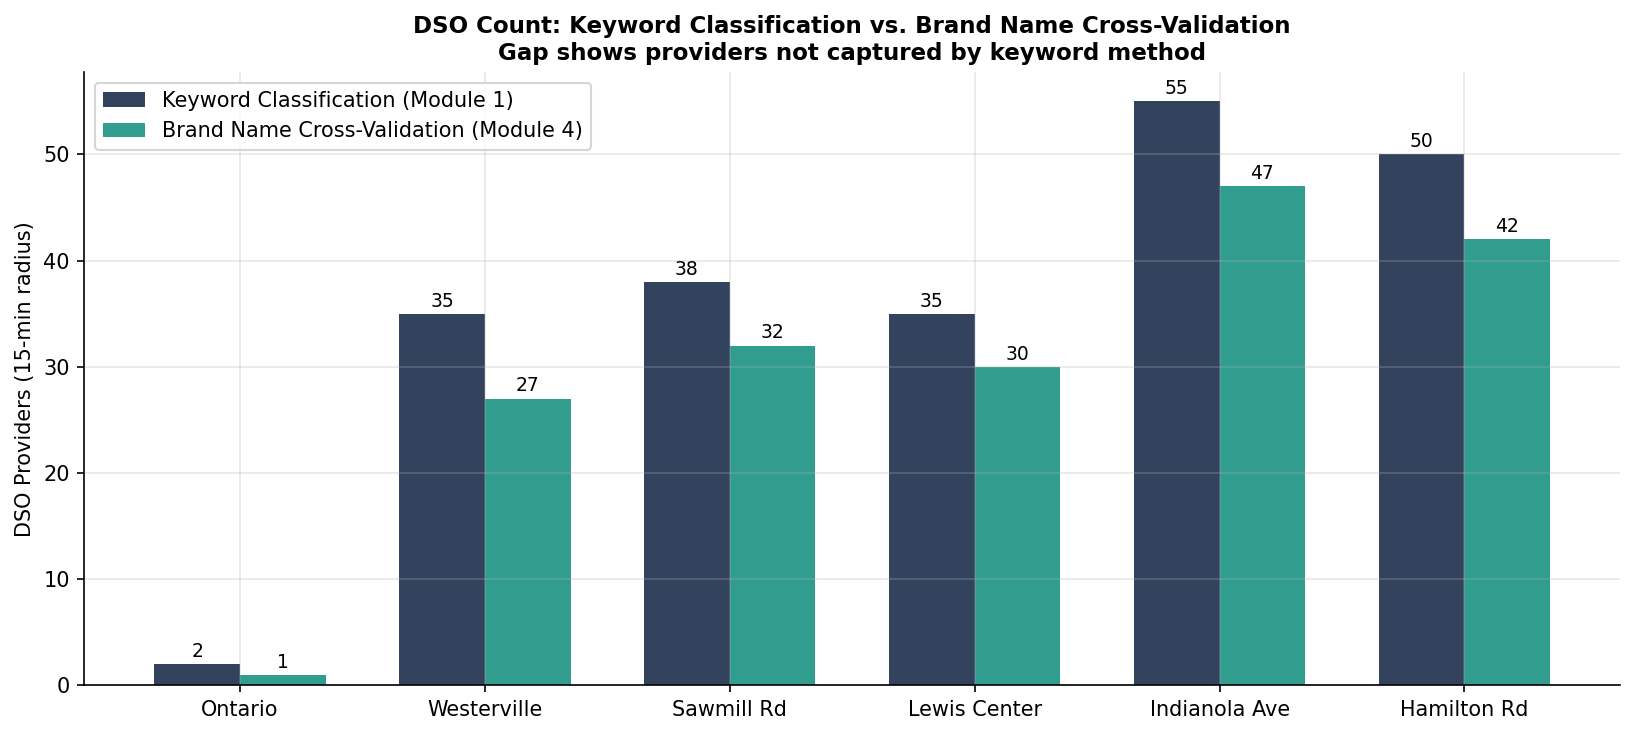

Chart 1 saved.


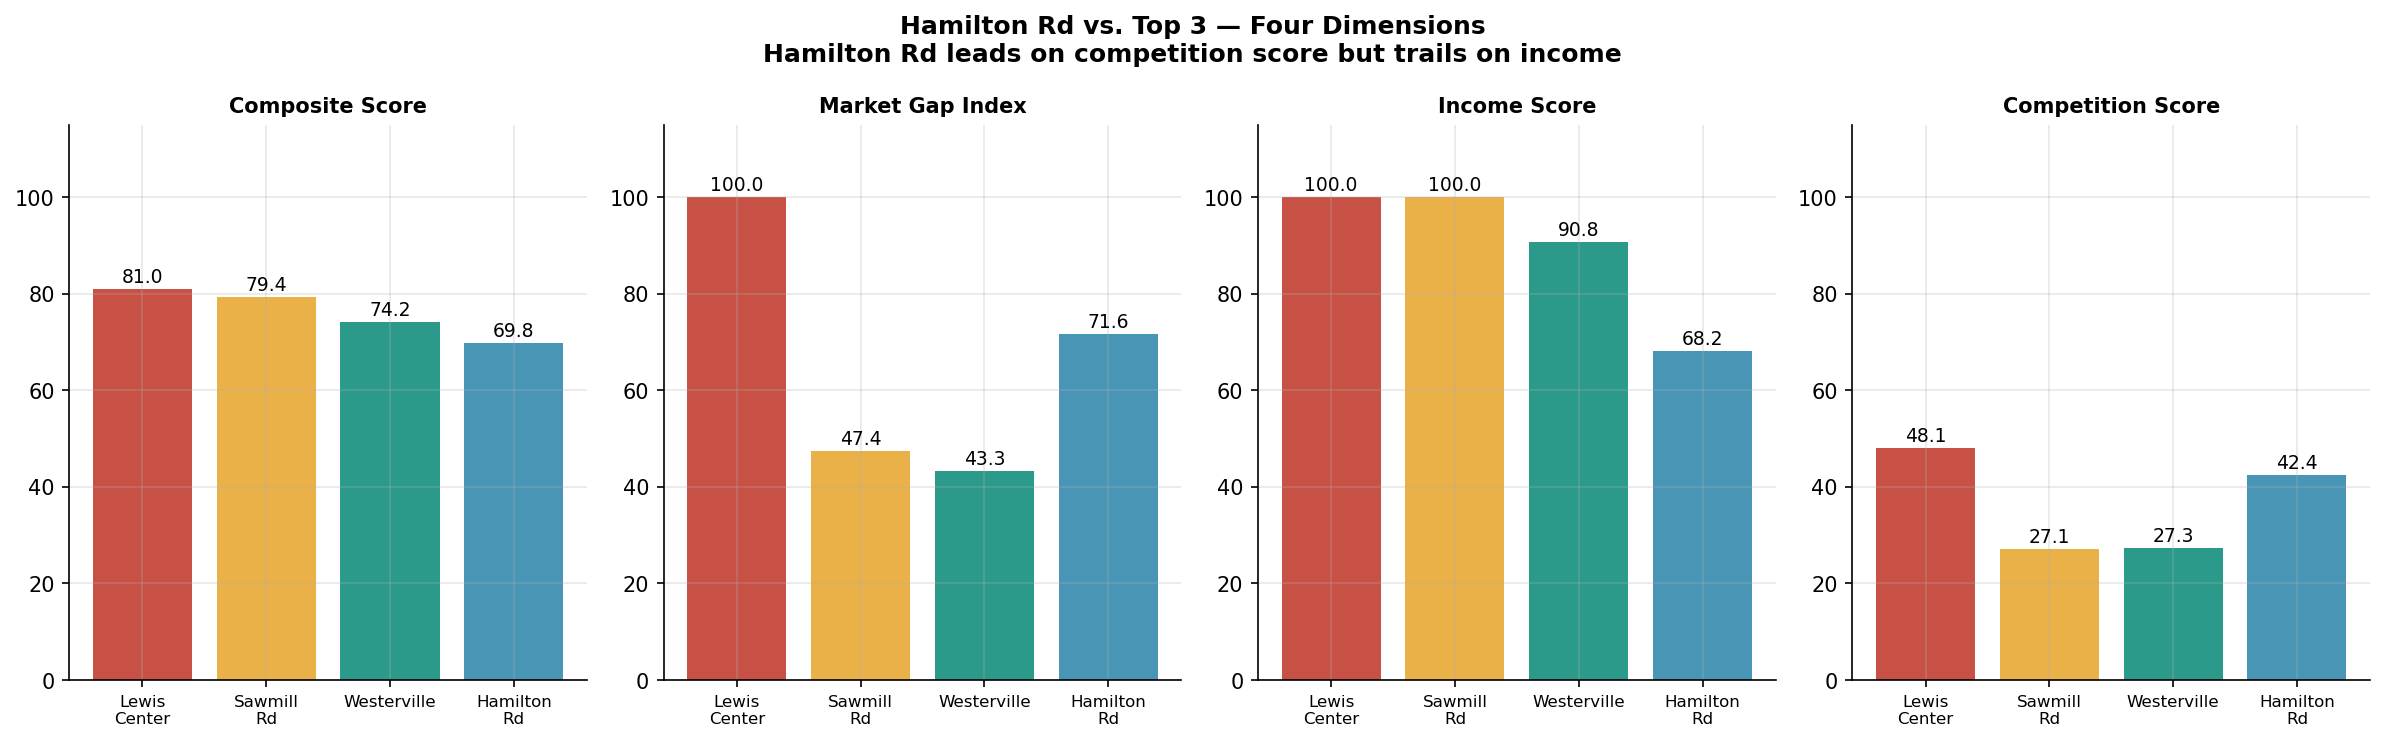

Chart 2 saved.


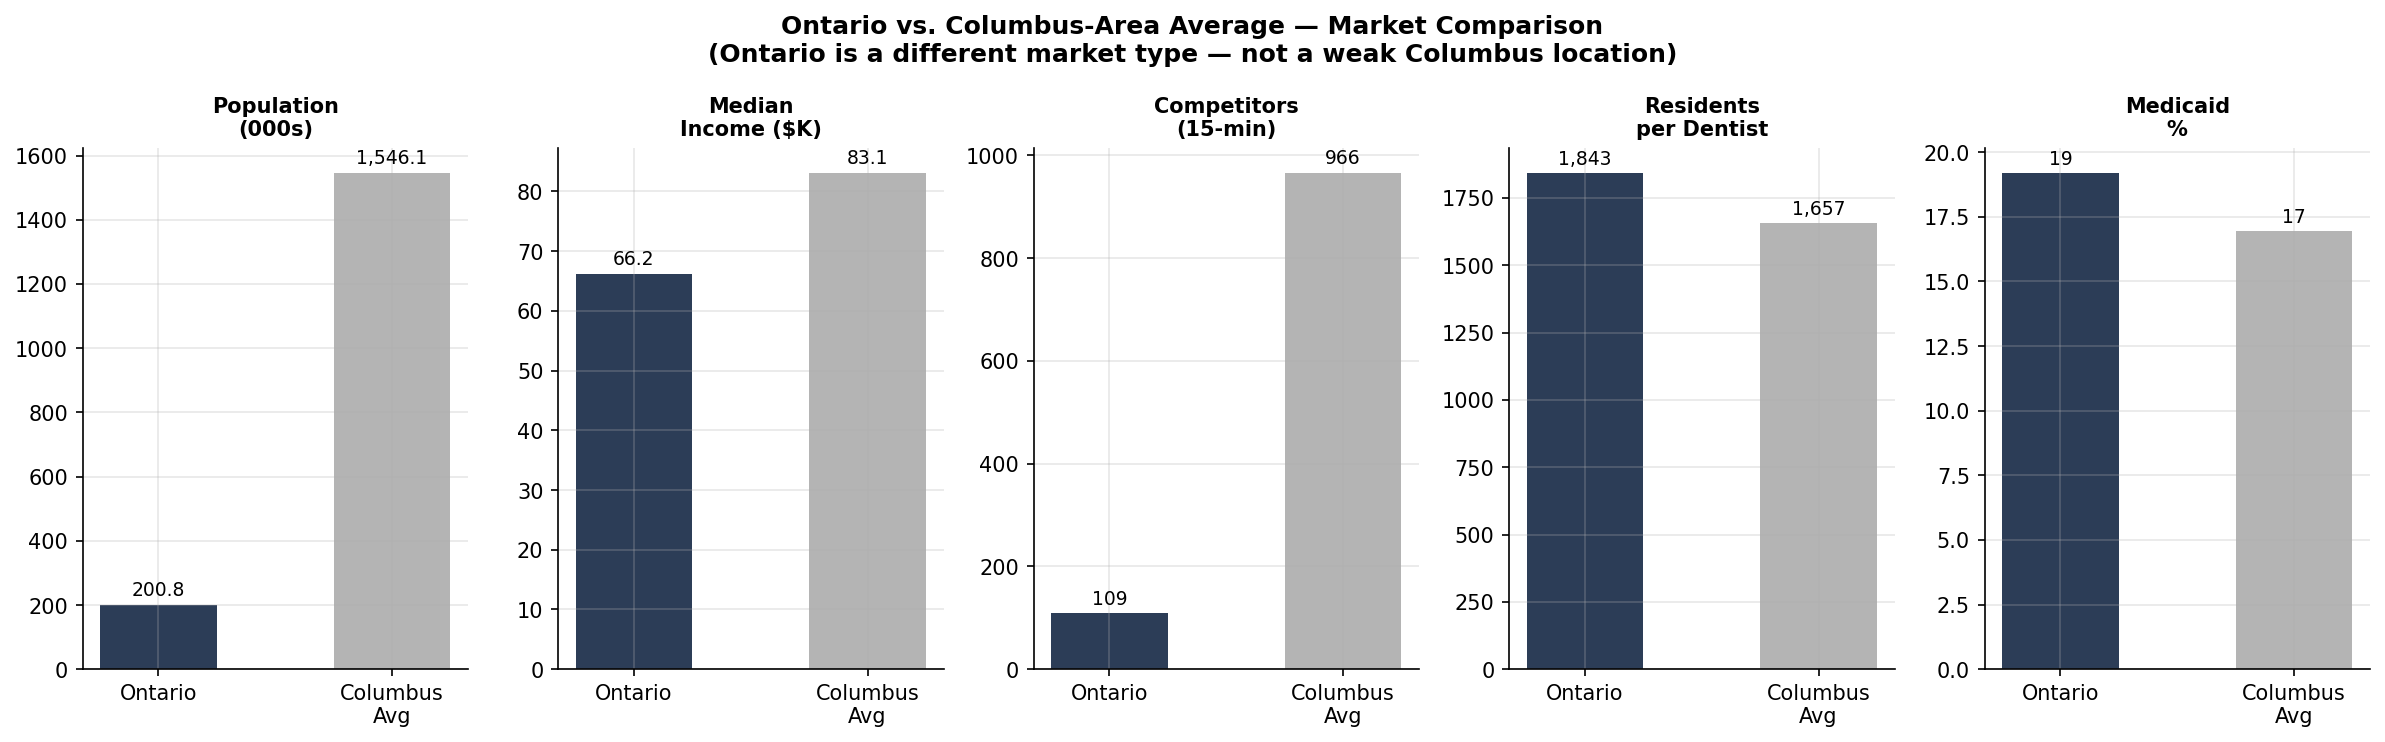

Chart 3 saved.


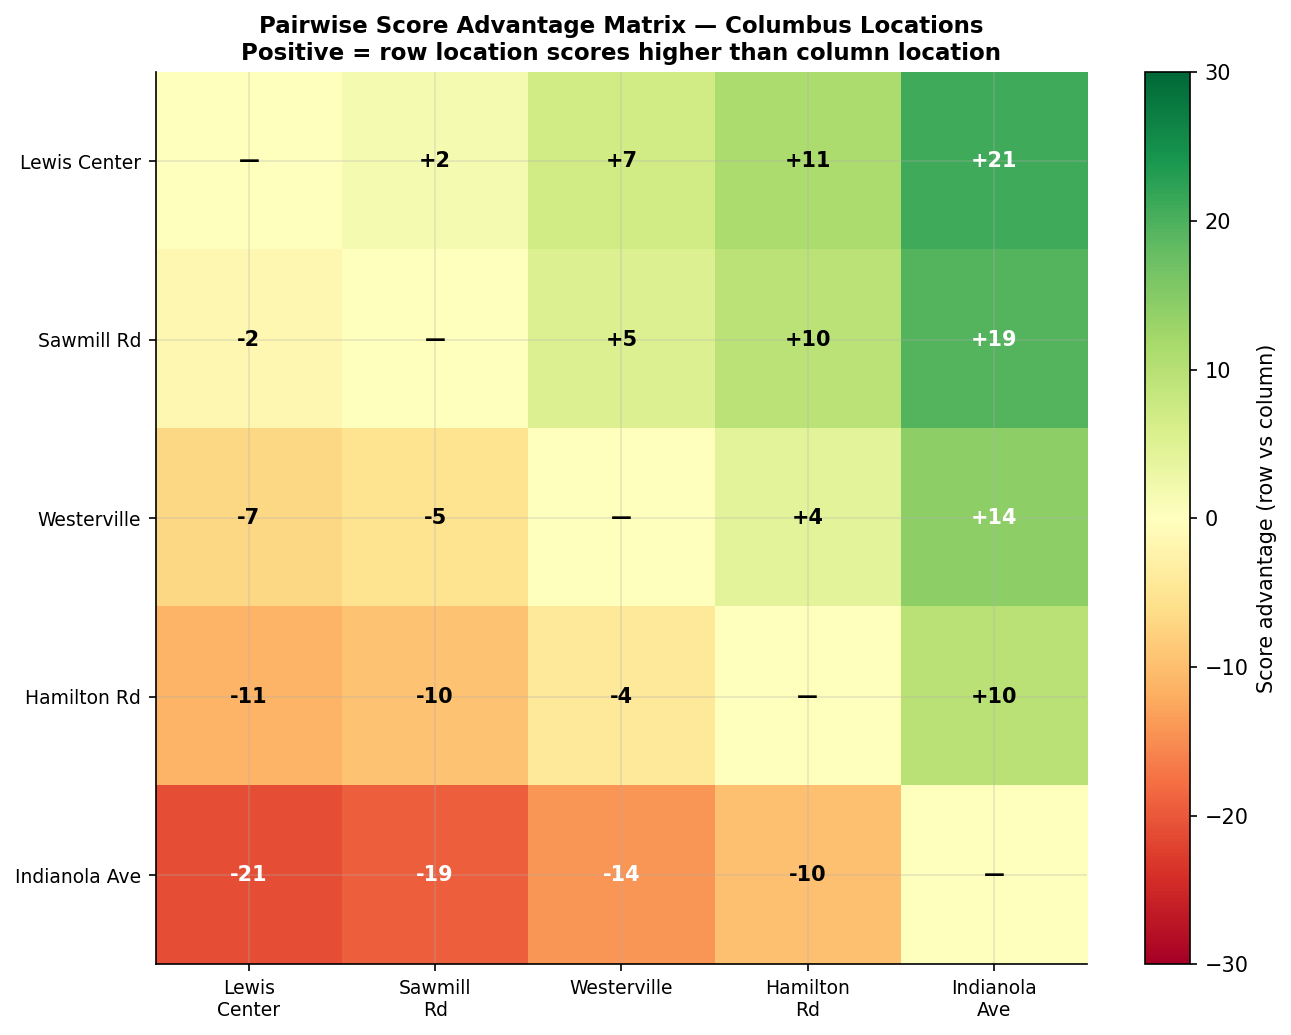

Chart 4 saved.


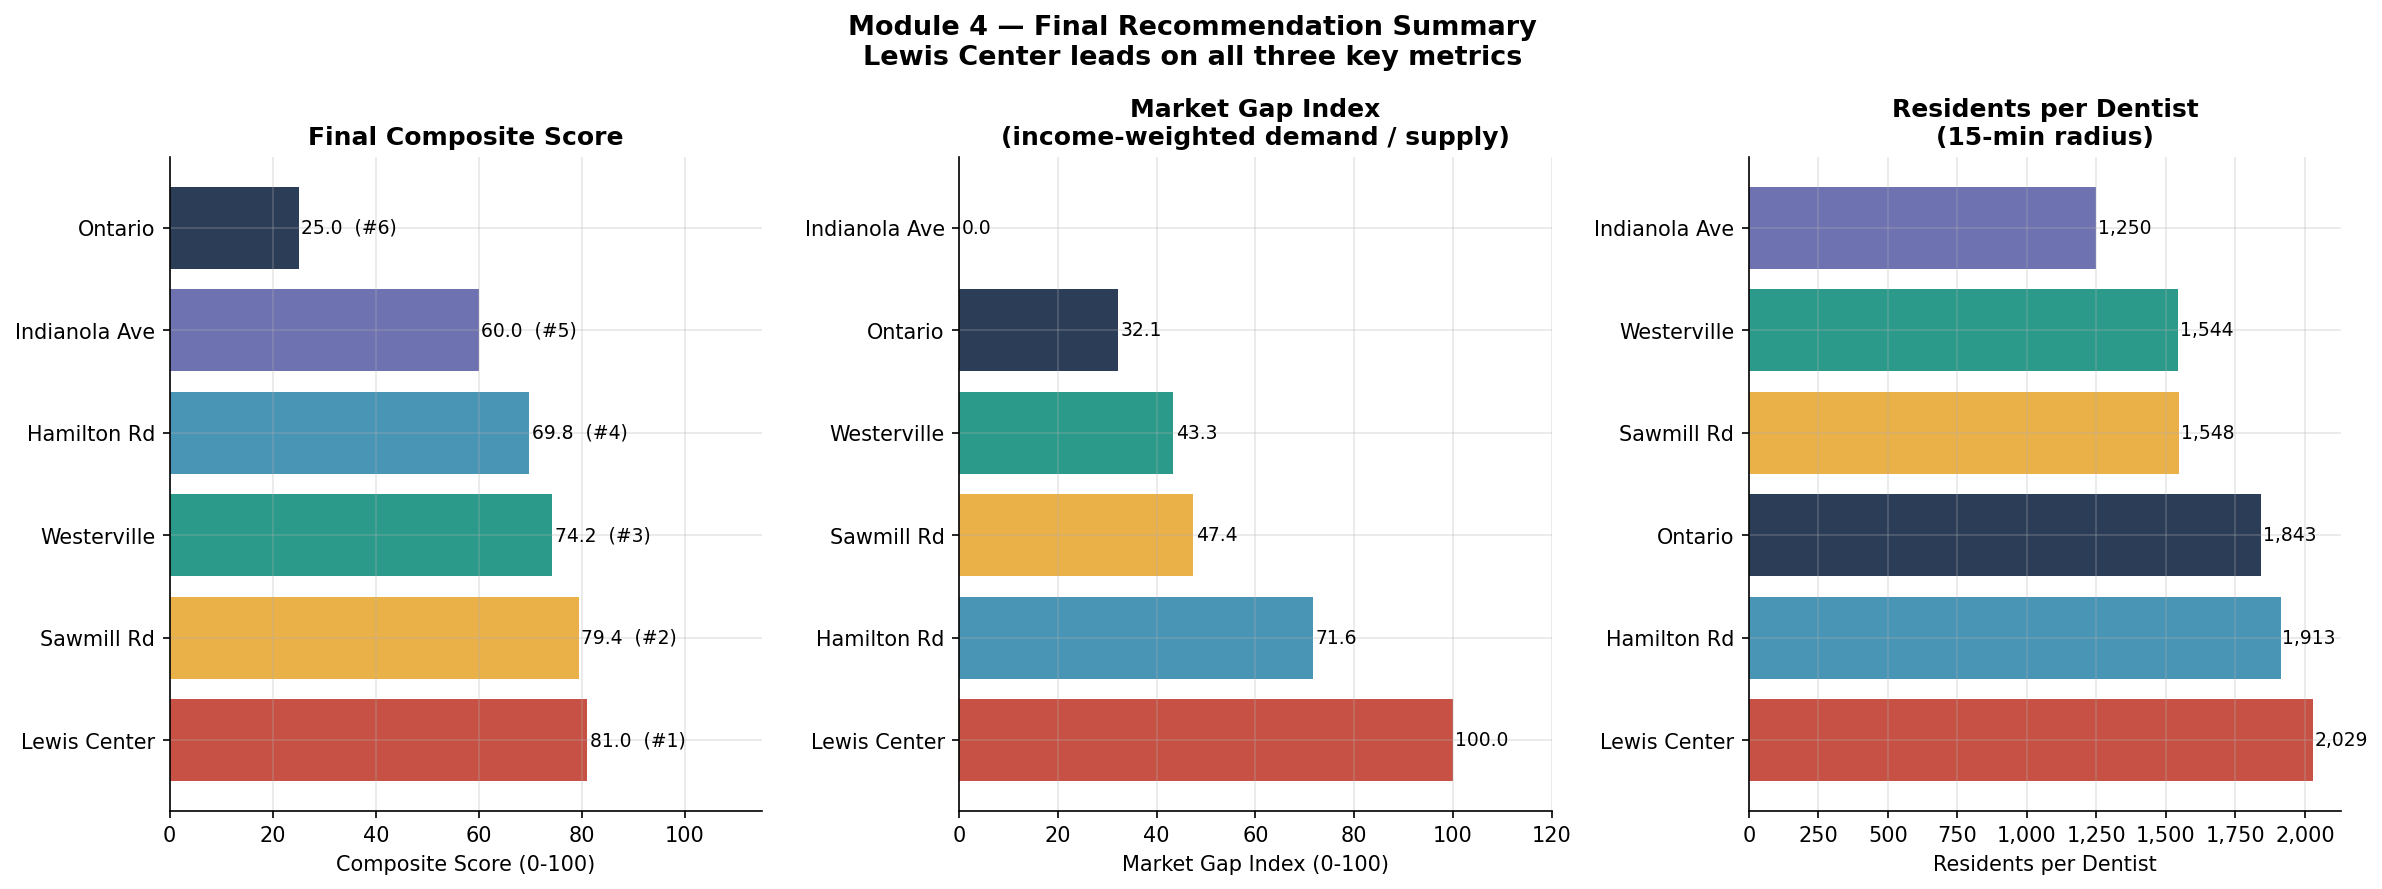

Chart 5 saved.


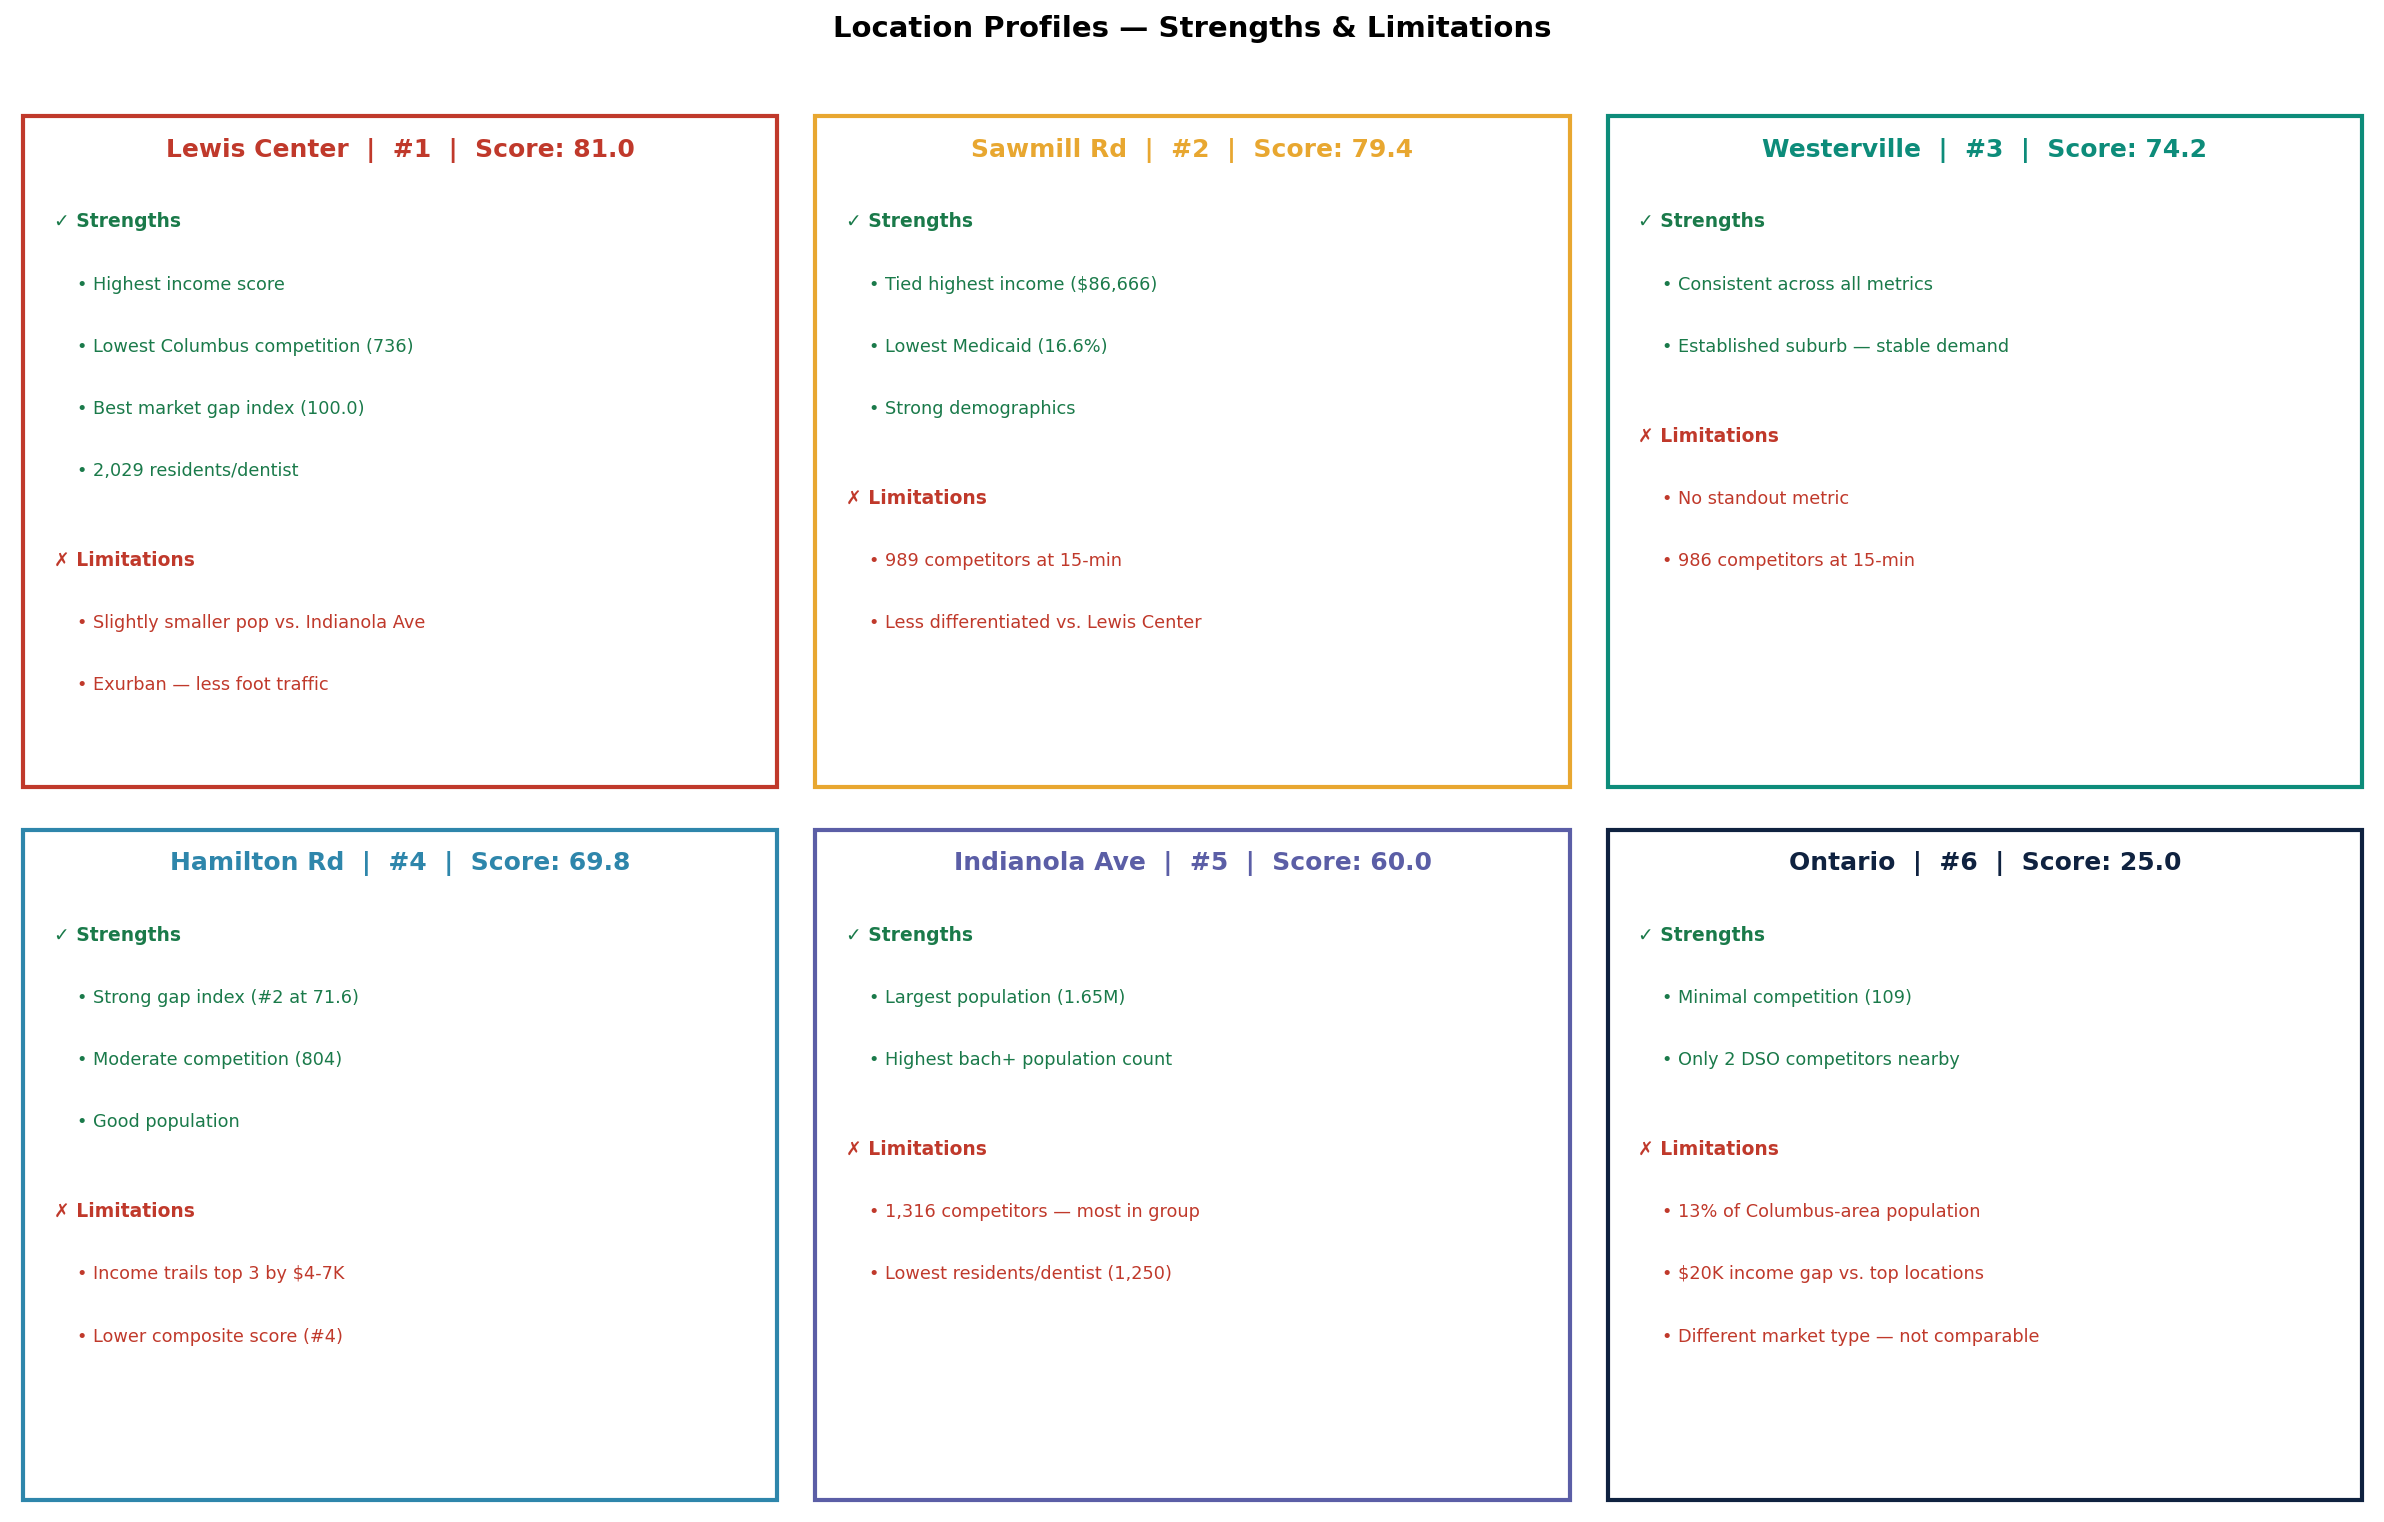

Chart 6 saved.

All charts saved to: ../charts/charts_m4


In [12]:
# CHART 1: DSO Cross-Validation 
fig, ax = plt.subplots(figsize=(11, 5))
x, width = np.arange(len(dso_compare)), 0.35
b1 = ax.bar(x - width/2, dso_compare["dso_15min"], width,
            label="Keyword Classification (Module 1)", color="#0F2240", alpha=0.85)
b2 = ax.bar(x + width/2, dso_compare["dso_brand_total_15min"], width,
            label="Brand Name Cross-Validation (Module 4)", color="#0D8C7A", alpha=0.85)
for bar, val in zip(b1, dso_compare["dso_15min"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(val)), ha="center", va="bottom", fontsize=9)
for bar, val in zip(b2, dso_compare["dso_brand_total_15min"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(val)), ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(dso_compare["location_name"], fontsize=10)
ax.set_ylabel("DSO Providers (15-min radius)")
ax.set_title("DSO Count: Keyword Classification vs. Brand Name Cross-Validation\n"
             "Gap shows providers not captured by keyword method",
             fontsize=11, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "01_dso_validation.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 1 saved.")

# CHART 2: Hamilton Rd Deep-Dive
compare_cols   = ["final_score", "market_gap", "n_inc", "n_comp"]
compare_labels = ["Composite Score", "Market Gap Index", "Income Score", "Competition Score"]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col, label in zip(axes, compare_cols, compare_labels):
    vals   = [df[df["location_name"] == loc][col].values[0] for loc in top3_locs]
    colors = [COLOR_MAP[loc] for loc in top3_locs]
    bars   = ax.bar(range(len(top3_locs)), vals, color=colors, alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(len(top3_locs)))
    ax.set_xticklabels([l.replace(" ", "\n") for l in top3_locs], fontsize=8)
    ax.set_title(label, fontweight="bold", fontsize=10)
    ax.set_ylim(0, 115)
plt.suptitle("Hamilton Rd vs. Top 3 — Four Dimensions\n"
             "Hamilton Rd leads on competition score but trails on income",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "02_hamilton_deepdive.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 2 saved.")

# CHART 3: Ontario vs. Columbus Comparison 
metrics_ont = {
    "Population\n(000s)":     ("total_population",     1000),
    "Median\nIncome ($K)":    ("median_income",         1000),
    "Competitors\n(15-min)":  ("total_15min",           1),
    "Residents\nper Dentist": ("residents_per_dentist", 1),
    "Medicaid\n%":            ("medicaid_pct",          1),
}
fig, axes = plt.subplots(1, len(metrics_ont), figsize=(16, 5))
for ax, (label, (col, divisor)) in zip(axes, metrics_ont.items()):
    ont_val = ontario[col] / divisor
    col_avg = columbus[col].mean() / divisor
    bars = ax.bar(["Ontario", "Columbus\nAvg"], [ont_val, col_avg],
                  color=["#0F2240", "#AAAAAA"], alpha=0.88, width=0.5)
    for bar, val in zip(bars, [ont_val, col_avg]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + col_avg * 0.01,
                f"{val:,.0f}" if divisor == 1 else f"{val:,.1f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(label, fontweight="bold", fontsize=10)
    ax.set_xticks([0, 1])
plt.suptitle("Ontario vs. Columbus-Area Average — Market Comparison\n"
             "(Ontario is a different market type — not a weak Columbus location)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "03_ontario_analysis.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 3 saved.")

# CHART 4: Pairwise Score Heatmap 
score_vals = [df[df["location_name"] == loc]["final_score"].values[0] for loc in columbus_locs]
score_arr  = np.zeros((len(columbus_locs), len(columbus_locs)))
for i in range(len(columbus_locs)):
    for j in range(len(columbus_locs)):
        score_arr[i, j] = score_vals[i] - score_vals[j]
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(score_arr, cmap="RdYlGn", vmin=-30, vmax=30, aspect="auto")
plt.colorbar(im, ax=ax, label="Score advantage (row vs column)")
short = [l.replace(" ", "\n") for l in columbus_locs]
ax.set_xticks(range(len(columbus_locs)))
ax.set_yticks(range(len(columbus_locs)))
ax.set_xticklabels(short, fontsize=9)
ax.set_yticklabels(columbus_locs, fontsize=9)
for i in range(len(columbus_locs)):
    for j in range(len(columbus_locs)):
        val   = score_arr[i, j]
        color = "white" if abs(val) > 12 else "black"
        txt   = f"+{val:.0f}" if val > 0 else (f"{val:.0f}" if val < 0 else "—")
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=10, color=color, fontweight="bold")
ax.set_title("Pairwise Score Advantage Matrix — Columbus Locations\n"
             "Positive = row location scores higher than column location",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "04_pairwise_heatmap.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 4 saved.")

# CHART 5: Final Recommendation Summary 
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
bar_colors = [COLOR_MAP[n] for n in df_ranked["location_name"]]
bars = axes[0].barh(df_ranked["location_name"], df_ranked["final_score"],
                    color=bar_colors, alpha=0.88)
for bar, val, rank in zip(bars, df_ranked["final_score"], df_ranked["final_rank"]):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}  (#{rank})", va="center", fontsize=9)
axes[0].set_xlabel("Composite Score (0-100)")
axes[0].set_title("Final Composite Score", fontweight="bold")
axes[0].set_xlim(0, 115)

gap_sorted  = df.sort_values("market_gap", ascending=False)
bar_colors2 = [COLOR_MAP[n] for n in gap_sorted["location_name"]]
bars2 = axes[1].barh(gap_sorted["location_name"], gap_sorted["market_gap"],
                     color=bar_colors2, alpha=0.88)
for bar, val in zip(bars2, gap_sorted["market_gap"]):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}", va="center", fontsize=9)
axes[1].set_xlabel("Market Gap Index (0-100)")
axes[1].set_title("Market Gap Index\n(income-weighted demand / supply)", fontweight="bold")
axes[1].set_xlim(0, 120)

rpd_sorted  = df.sort_values("residents_per_dentist", ascending=False)
bar_colors3 = [COLOR_MAP[n] for n in rpd_sorted["location_name"]]
bars3 = axes[2].barh(rpd_sorted["location_name"], rpd_sorted["residents_per_dentist"],
                     color=bar_colors3, alpha=0.88)
for bar, val in zip(bars3, rpd_sorted["residents_per_dentist"]):
    axes[2].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f"{val:,.0f}", va="center", fontsize=9)
axes[2].set_xlabel("Residents per Dentist")
axes[2].set_title("Residents per Dentist\n(15-min radius)", fontweight="bold")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.suptitle("Module 4 — Final Recommendation Summary\n"
             "Lewis Center leads on all three key metrics",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "05_final_recommendation.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 5 saved.")

# CHART 6: Pros/Cons Summary 
pros_cons = {
    "Lewis Center":  {
        "pros": ["Highest income score", "Lowest Columbus competition (736)",
                 "Best market gap index (100.0)", "2,029 residents/dentist"],
        "cons": ["Slightly smaller pop vs. Indianola Ave", "Exurban — less foot traffic"]},
    "Sawmill Rd":    {
        "pros": ["Tied highest income ($86,666)", "Lowest Medicaid (16.6%)", "Strong demographics"],
        "cons": ["989 competitors at 15-min", "Less differentiated vs. Lewis Center"]},
    "Westerville":   {
        "pros": ["Consistent across all metrics", "Established suburb — stable demand"],
        "cons": ["No standout metric", "986 competitors at 15-min"]},
    "Hamilton Rd":   {
        "pros": ["Strong gap index (#2 at 71.6)", "Moderate competition (804)", "Good population"],
        "cons": ["Income trails top 3 by $4-7K", "Lower composite score (#4)"]},
    "Indianola Ave": {
        "pros": ["Largest population (1.65M)", "Highest bach+ population count"],
        "cons": ["1,316 competitors — most in group", "Lowest residents/dentist (1,250)"]},
    "Ontario":       {
        "pros": ["Minimal competition (109)", "Only 2 DSO competitors nearby"],
        "cons": ["13% of Columbus-area population", "$20K income gap vs. top locations",
                 "Different market type — not comparable"]},
}
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for idx, (loc, data) in enumerate(pros_cons.items()):
    ax  = axes[idx]
    clr = COLOR_MAP[loc]
    ax.axis("off")
    score = df[df["location_name"] == loc]["final_score"].values[0]
    rank  = df[df["location_name"] == loc]["final_rank"].values[0]
    ax.text(0.5, 0.95, f"{loc}  |  #{rank}  |  Score: {score:.1f}",
            transform=ax.transAxes, ha="center", va="top",
            fontsize=12, fontweight="bold", color=clr)
    y = 0.82
    ax.text(0.05, y, "✓ Strengths", transform=ax.transAxes,
            fontsize=9, fontweight="bold", color="#1A7A4A")
    y -= 0.09
    for pro in data["pros"]:
        ax.text(0.08, y, f"• {pro}", transform=ax.transAxes,
                fontsize=8.5, color="#1A7A4A")
        y -= 0.09
    y -= 0.04
    ax.text(0.05, y, "✗ Limitations", transform=ax.transAxes,
            fontsize=9, fontweight="bold", color="#C0392B")
    y -= 0.09
    for con in data["cons"]:
        ax.text(0.08, y, f"• {con}", transform=ax.transAxes,
                fontsize=8.5, color="#C0392B")
        y -= 0.09
    rect = plt.Rectangle((0.01, 0.01), 0.98, 0.97, fill=False,
                          edgecolor=clr, linewidth=2,
                          transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
plt.suptitle("Location Profiles — Strengths & Limitations",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "06_pros_cons.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 6 saved.")

print("\nAll charts saved to:", CHARTS_PATH)

In [14]:
# FULL SUMMARY
print("=" * 70)
print("MODULE 4 — FULL SUMMARY OUTPUT")
print("=" * 70)

print("\n--- FINAL SCORES ---")
for _, row in df_ranked.iterrows():
    print(f"  #{int(row['final_rank'])}  {row['location_name']:<16}  "
          f"Score={row['final_score']:.1f}  "
          f"GapIdx={row['market_gap']:.1f}  "
          f"Res/Dentist={row['residents_per_dentist']:,.0f}")

print("\n--- DSO CROSS-VALIDATION ---")
for _, row in dso_compare.iterrows():
    print(f"  {row['location_name']:<16}  "
          f"Keyword={int(row['dso_15min'])} ({row['keyword_dso_pct']:.1f}%)  "
          f"Brand={int(row['dso_brand_total_15min'])} ({row['brand_dso_pct']:.1f}%)  "
          f"Gap={int(row['gap'])}")

print("\n--- ONTARIO REVENUE PROXY ---")
print(f"  Columbus avg (1,500 visits @ $350): ${columbus_rev:,.0f}/year")
print(f"  Ontario income-adjusted:            ${ontario_rev:,.0f}/year")
print(f"  Revenue gap:                        ${columbus_rev - ontario_rev:,.0f}/year")

print("\n--- PAIRWISE WINNERS (Columbus only) ---")
win_counts = tradeoff_df["winner"].value_counts()
for loc, wins in win_counts.items():
    total = len(columbus_locs) - 1
    print(f"  {loc:<16}  wins {wins}/{total} pairwise matchups")

print("\nOutputs saved:")
print(f"  {os.path.join(OUTPUT_PATH, 'module4_final_scores.csv')}")
print(f"  {os.path.join(OUTPUT_PATH, 'module4_tradeoff.csv')}")
print(f"  {CHARTS_PATH}/ (6 PNG files)")

MODULE 4 — FULL SUMMARY OUTPUT

--- FINAL SCORES ---
  #1  Lewis Center      Score=81.0  GapIdx=100.0  Res/Dentist=2,029
  #2  Sawmill Rd        Score=79.4  GapIdx=47.4  Res/Dentist=1,548
  #3  Westerville       Score=74.2  GapIdx=43.3  Res/Dentist=1,544
  #4  Hamilton Rd       Score=69.8  GapIdx=71.6  Res/Dentist=1,913
  #5  Indianola Ave     Score=60.0  GapIdx=0.0  Res/Dentist=1,250
  #6  Ontario           Score=25.0  GapIdx=32.1  Res/Dentist=1,843

--- DSO CROSS-VALIDATION ---
  Ontario           Keyword=2 (1.8%)  Brand=1 (0.9%)  Gap=-1
  Westerville       Keyword=35 (3.5%)  Brand=27 (2.7%)  Gap=-8
  Sawmill Rd        Keyword=38 (3.8%)  Brand=32 (3.2%)  Gap=-6
  Lewis Center      Keyword=35 (4.8%)  Brand=30 (4.1%)  Gap=-5
  Indianola Ave     Keyword=55 (4.2%)  Brand=47 (3.6%)  Gap=-8
  Hamilton Rd       Keyword=50 (6.2%)  Brand=42 (5.2%)  Gap=-8

--- ONTARIO REVENUE PROXY ---
  Columbus avg (1,500 visits @ $350): $525,000/year
  Ontario income-adjusted:            $418,510/year
  Re